<a href="https://colab.research.google.com/github/Yuv4n/Andrej-Karpathy-Course/blob/main/micrograd_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)) #Only supporting integers and floats for now
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other):# other * self
        return self * other

    def __radd__(self, other):# other + self
        return self + other

    def __truediv__(self, other):
        return self * other**-1

    def __rtruediv__(self, other):
        return other * self**-1

    def __neg__(self):# - self
        return self * -1

    def __sub__(self, other):
        return self + (other * -1)

    def __rsub__(self, other):
        return other + (self * -1)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')


        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self, ), 'ReLU')

        def _backward():
            self.grad += (self.data > 0) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f'Value(data={self.data}, grad={self.grad})'

In [ ]:
# Not Relevant, just for visualisation

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

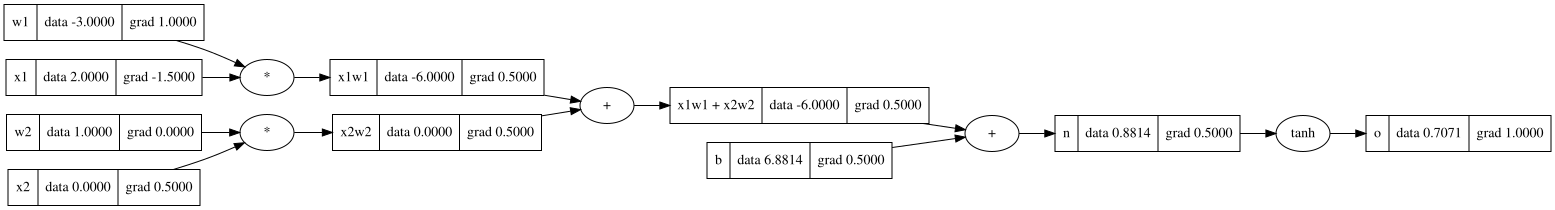

In [ ]:
draw_dot(o)

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()

In [ ]:
import torch

In [ ]:

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [ ]:
# zero grad
class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

    def parameters(self):
        return []

class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        self.nonlin = nonlin

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.relu() if self.nonlin else act # chose ReLU activation function over tanh
        # linear is a weighted sum that act as decision boundaries (stacking lin layers w/out activation func remain lin)
        # nonlin operation applies an activation function, bends mapping allows to learn curves/complex patterns
        # hidden layers need nonlin output to make depth useful
        # final output may remain linear when depth is necessay
        return out

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        # final layer must not be ReLU, as it forces the outputs to be non-negative
        # predictions may be negative, so we do not want ReLU on the output layer
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i != len(nouts) - 1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.5782350323101892, grad=0.0)

In [ ]:
k = 0
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # measures error of prediction, MSE
#GPT models use cross entropy loss instead of MSE

while loss.data > 0.01:
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters(): # zero grad before backward
        p.grad = 0.0
    loss.backward()

    # simple stochastic gradient descent update
    for p in n.parameters():
        p.data += -0.01 * p.grad # tuning learning rate

        # be careful, switching activation frunction from tanh to ReLU caused dead neurons (gradients can be 0)
        # too many dead neurons stops improvement
        # this keeps occuring around 4.0
        # tanh does not have this issue as it doesn't have the same hard cutoff so it keeps learning more easily

        # too large laerning rate breaks algorithm, becomes unstable (unlikely as loss was constant @ 4)
        # decreasing learning rate still fixed dead neurons(0.05 > 0.01)

    k += 1
    print(k, loss.data)
ypred

1 14.5804585514232
2 7.012734092231131
3 5.6087837384757595
4 5.019361383993887
5 4.645035580459275
6 4.379475199306213
7 4.175446269856393
8 4.008653954059048
9 3.8654422178633645
10 3.737772544882525
11 3.6209001901433897
12 3.5121823969827557
13 3.4103949189220426
14 3.315278321260822
15 3.2271827761731746
16 3.1467554621581857
17 3.062978624672664
18 2.947425474888069
19 2.8348370189811436
20 2.727627581508144
21 2.666292655251575
22 2.591549591667236
23 2.5556625488115996
24 2.492121896757724
25 2.4512181823829984
26 2.404080680632558
27 2.3613590899661565
28 2.320104387096845
29 2.2791974033368696
30 2.2371259857011596
31 2.200719812183141
32 2.15412925388111
33 2.1237218252680425
34 2.0707251137311946
35 2.0469655381580374
36 1.9866274406134743
37 1.969717102643346
38 1.9035476862659824
39 1.8908616701826535
40 1.8301494036771244
41 1.7973389728384017
42 1.7537219673301865
43 1.7047240534117931
44 1.674924875200632
45 1.6116056032604984
46 1.5941262822798263
47 1.528518216612917

[Value(data=0.9308183188651247, grad=-0.13836336226975066),
 Value(data=-1.0041383485164053, grad=-0.008276697032810532),
 Value(data=-0.9798434341916507, grad=0.040313131616698694),
 Value(data=0.9308183188651247, grad=-0.13836336226975066)]

In [ ]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 0.00925312441134624
1 0.006115206106136001
2 0.004068558445010067
3 0.0031493457877338053
4 0.006216546759522711
5 0.020129238500164955
6 0.09404276129597086
7 0.44416350041276464
8 2.609367843998165
9 2.8904907046795474
10 8.447414135023287
11 5.21970832465906
12 3.6249353531387536
13 1.8218014256728434
14 0.9537708567428398
15 0.6257553961687694
16 0.4147911500609234
17 0.27953537442896625
18 0.19862689043564508
19 0.16961578484006842


In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)) #Only supporting integers and floats for now
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other):# other * self
        return self * other

    def __radd__(self, other):# other + self
        return self + other

    def __truediv__(self, other):
        return self * other**-1

    def __rtruediv__(self, other):
        return other * self**-1

    def __neg__(self):# - self
        return self * -1

    def __sub__(self, other):
        return self + (other * -1)

    def __rsub__(self, other):
        return other + (self * -1)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')


        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self, ), 'ReLU')

        def _backward():
            self.grad += (self.data > 0) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f'Value(data={self.data}, grad={self.grad})'

In [ ]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0, grad=0.0)

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()

In [ ]:
import torch

In [ ]:

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [ ]:
# zero grad
class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

    def parameters(self):
        return []

class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        self.nonlin = nonlin

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.relu() if self.nonlin else act # chose ReLU activation function over tanh
        # linear is a weighted sum that act as decision boundaries (stacking lin layers w/out activation func remain lin)
        # nonlin operation applies an activation function, bends mapping allows to learn curves/complex patterns
        # hidden layers need nonlin output to make depth useful
        # final output may remain linear when depth is necessay
        return out

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        # final layer must not be ReLU, as it forces the outputs to be non-negative
        # predictions may be negative, so we do not want ReLU on the output layer
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i != len(nouts) - 1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-3.260196546335952, grad=0.0)

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
loss.data

0.16961578484006842

In [ ]:
k = 0
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # measures error of prediction, MSE
#GPT models use cross entropy loss instead of MSE

while loss.data > 0.01:
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters(): # zero grad before backward
        p.grad = 0.0
    loss.backward()

    # simple stochastic gradient descent update
    for p in n.parameters():
        p.data += -0.01 * p.grad # tuning learning rate

        # be careful, switching activation frunction from tanh to ReLU caused dead neurons (gradients can be 0)
        # too many dead neurons stops improvement
        # this keeps occuring around 4.0
        # tanh does not have this issue as it doesn't have the same hard cutoff so it keeps learning more easily

        # too large laerning rate breaks algorithm, becomes unstable (unlikely as loss was constant @ 4)
        # decreasing learning rate still fixed dead neurons(0.05 > 0.01)

    k += 1
    print(k, loss.data)
ypred

1 22.929327124997585
2 4.38023719774092
3 3.7700719297327314
4 3.5942826980981346
5 3.5017099384438355
6 3.4152663455569243
7 3.3183761007321286
8 3.2063183653528835
9 3.076355502959876
10 2.9260879419995605
11 2.7534138867003337
12 2.556916789264519
13 2.3365200017198435
14 2.0943772350799215
15 1.8358706996463168
16 1.5703607939630495
17 1.362004618440775
18 1.2507917967755051
19 1.1579414489779598
20 1.0723795589994518
21 0.9910581388148139
22 0.9132506338862048
23 0.8389426992738878
24 0.7683083438375037
25 0.7015497623624243
26 0.6388465366084042
27 0.5803361960946476
28 0.5261044286956003
29 0.491604970013424
30 0.4588876836741739
31 0.4302408344944845
32 0.4041560485812092
33 0.3802803071825879
34 0.3559163684779503
35 0.3331393115242607
36 0.3116497394607408
37 0.29134884474851785
38 0.2721821644318208
39 0.25431997488324526
40 0.2390446554817344
41 0.22227716771591505
42 0.20698259694036464
43 0.19271431743059586
44 0.1793528637096002
45 0.16684184134700003
46 0.15513688779392

[Value(data=0.9315610790865102, grad=-0.1368778418269796),
 Value(data=-1.0067545068623525, grad=-0.013509013724704921),
 Value(data=-0.9781358894969147, grad=0.04372822100617069),
 Value(data=0.9315610790865102, grad=-0.1368778418269796)]

In [ ]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 0.009182605244671831
1 0.006139022597850555
2 0.004106312293890759
3 0.002816703525019409
4 0.0027243839238612175
5 0.006114624924623139
6 0.030670087896029284
7 0.18774975237833136
8 1.2590047349936804
9 4.775743685896114
10 10.215859988961826
11 6.1719102610299705
12 4.7741297324742025
13 4.278686703690712
14 4.100327213328657
15 4.036117796798316
16 4.013002406847394
17 4.004680866465062
18 4.001685111927422
19 4.000606640293872


In [ ]:
ypred

[Value(data=0.012315034448510592, grad=-1.9753699311029789),
 Value(data=0.012315034448510592, grad=2.024630068897021),
 Value(data=0.012315034448510592, grad=2.024630068897021),
 Value(data=0.012315034448510592, grad=-1.9753699311029789)]